# **Proyecto de consultoría**
## Abandono de clientes
- Fabiola Contreras 22787
- María Villafuerte 22129

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.patches import Rectangle

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [4]:
# 1. CARGA DE DATOS
df = pd.read_csv('abandono_clientes.csv')
df_nuevos = pd.read_csv('clientes_nuevos.csv')

In [5]:
# 2. INFORMACIÓN BÁSICA
print("\nINFORMACIÓN GENERAL DEL DATASET")
print("-"*60)
print(f"Dimensiones: {df.shape}")
print(f"\nPrimeras filas:")
print(df.head())
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nInformación del DataFrame:")
df.info()


INFORMACIÓN GENERAL DEL DATASET
------------------------------------------------------------
Dimensiones: (900, 10)

Primeras filas:
              Names   Age  Total_Purchase  Account_Manager  Years  Num_Sites  \
0  Cameron Williams  42.0        11066.80                0   7.22        8.0   
1     Kevin Mueller  41.0        11916.22                0   6.50       11.0   
2       Eric Lozano  38.0        12884.75                0   6.67       12.0   
3     Phillip White  42.0         8010.76                0   6.71       10.0   
4    Cynthia Norton  37.0         9191.58                0   5.56        9.0   

          Onboard_date                                           Location  \
0  2013-08-30 07:00:40      10265 Elizabeth Mission Barkerburgh, AK 89518   
1  2013-08-13 00:38:46  6157 Frank Gardens Suite 019 Carloshaven, RI 1...   
2  2016-06-29 06:20:07             1331 Keith Court Alyssahaven, DE 90114   
3  2014-04-22 12:43:12       13120 Daniel Mount Angelabury, WY 30645-4695   



ANÁLISIS DE VALORES FALTANTES
------------------------------------------------------------
Empty DataFrame
Columns: [Columna, Valores Faltantes, Porcentaje (%)]
Index: []


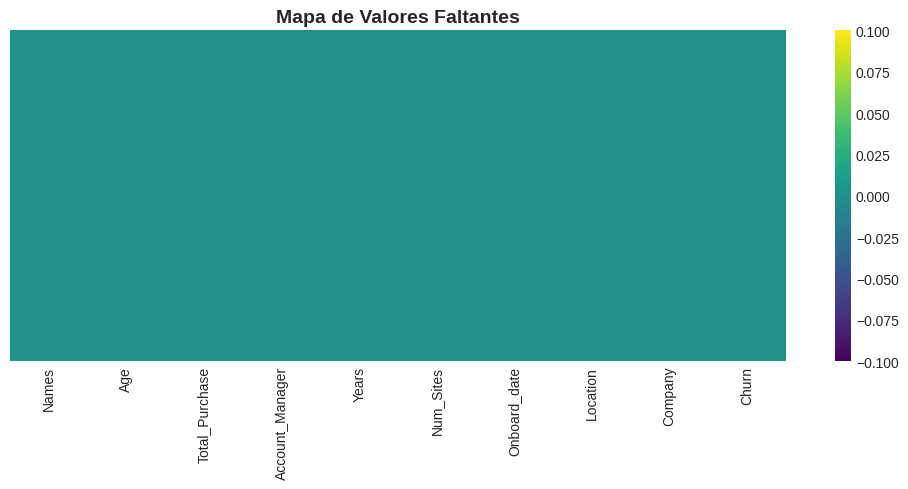

In [6]:
# 3. VALORES FALTANTES
print("\nANÁLISIS DE VALORES FALTANTES")
print("-"*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Columna': missing.index,
    'Valores Faltantes': missing.values,
    'Porcentaje (%)': missing_pct.values
})
print(missing_df[missing_df['Valores Faltantes'] > 0])

# Gráfica de valores faltantes
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Mapa de Valores Faltantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# 4. ESTADÍSTICAS DESCRIPTIVAS
print("\nESTADÍSTICAS DESCRIPTIVAS")
print("-"*60)
print(df.describe())


ESTADÍSTICAS DESCRIPTIVAS
------------------------------------------------------------
              Age  Total_Purchase  Account_Manager       Years   Num_Sites  \
count  900.000000      900.000000       900.000000  900.000000  900.000000   
mean    41.816667    10062.824033         0.481111    5.273156    8.587778   
std      6.127560     2408.644532         0.499921    1.274449    1.764836   
min     22.000000      100.000000         0.000000    1.000000    3.000000   
25%     38.000000     8497.122500         0.000000    4.450000    7.000000   
50%     42.000000    10045.870000         0.000000    5.215000    8.000000   
75%     46.000000    11760.105000         1.000000    6.110000   10.000000   
max     65.000000    18026.010000         1.000000    9.150000   14.000000   

            Churn  
count  900.000000  
mean     0.166667  
std      0.372885  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      0.000000  
max      1.000000  



DISTRIBUCIÓN DE CHURN
------------------------------------------------------------

Conteo:
Churn
0    750
1    150
Name: count, dtype: int64

Porcentaje:
Churn
0    83.333333
1    16.666667
Name: proportion, dtype: float64


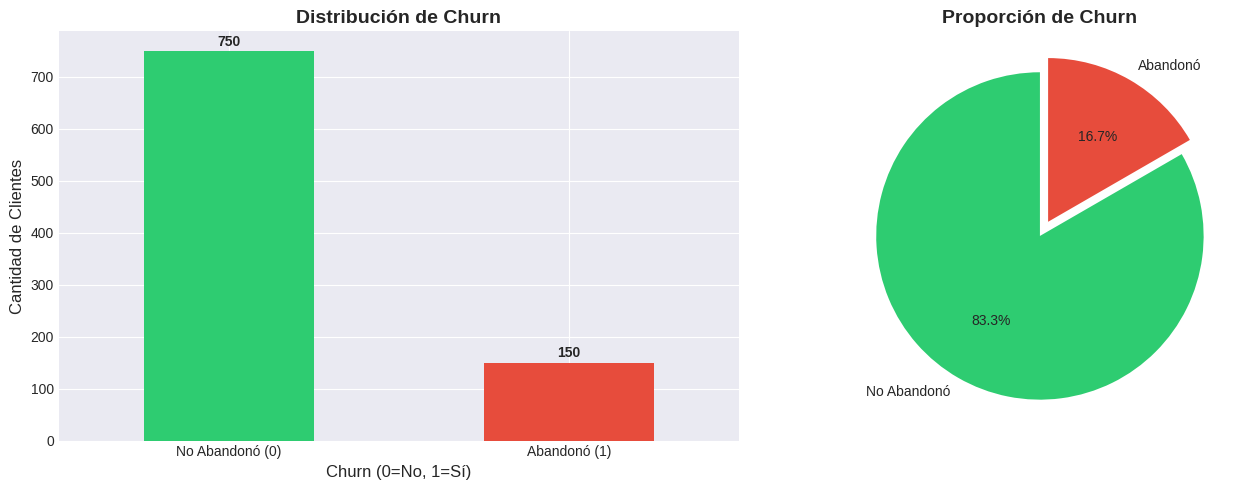

In [8]:
# 5. DISTRIBUCIÓN DE CHURN (VARIABLE OBJETIVO)
print("\nDISTRIBUCIÓN DE CHURN")
print("-"*60)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f"\nConteo:\n{churn_counts}")
print(f"\nPorcentaje:\n{churn_pct}")

# Gráficas de Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de barras
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0=No, 1=Sí)', fontsize=12)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=12)
axes[0].set_xticklabels(['No Abandonó (0)', 'Abandonó (1)'], rotation=0)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Gráfica de pastel
axes[1].pie(churn_counts, labels=['No Abandonó', 'Abandonó'],
            autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.1))
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



🔢 ANÁLISIS DE VARIABLES NUMÉRICAS
------------------------------------------------------------


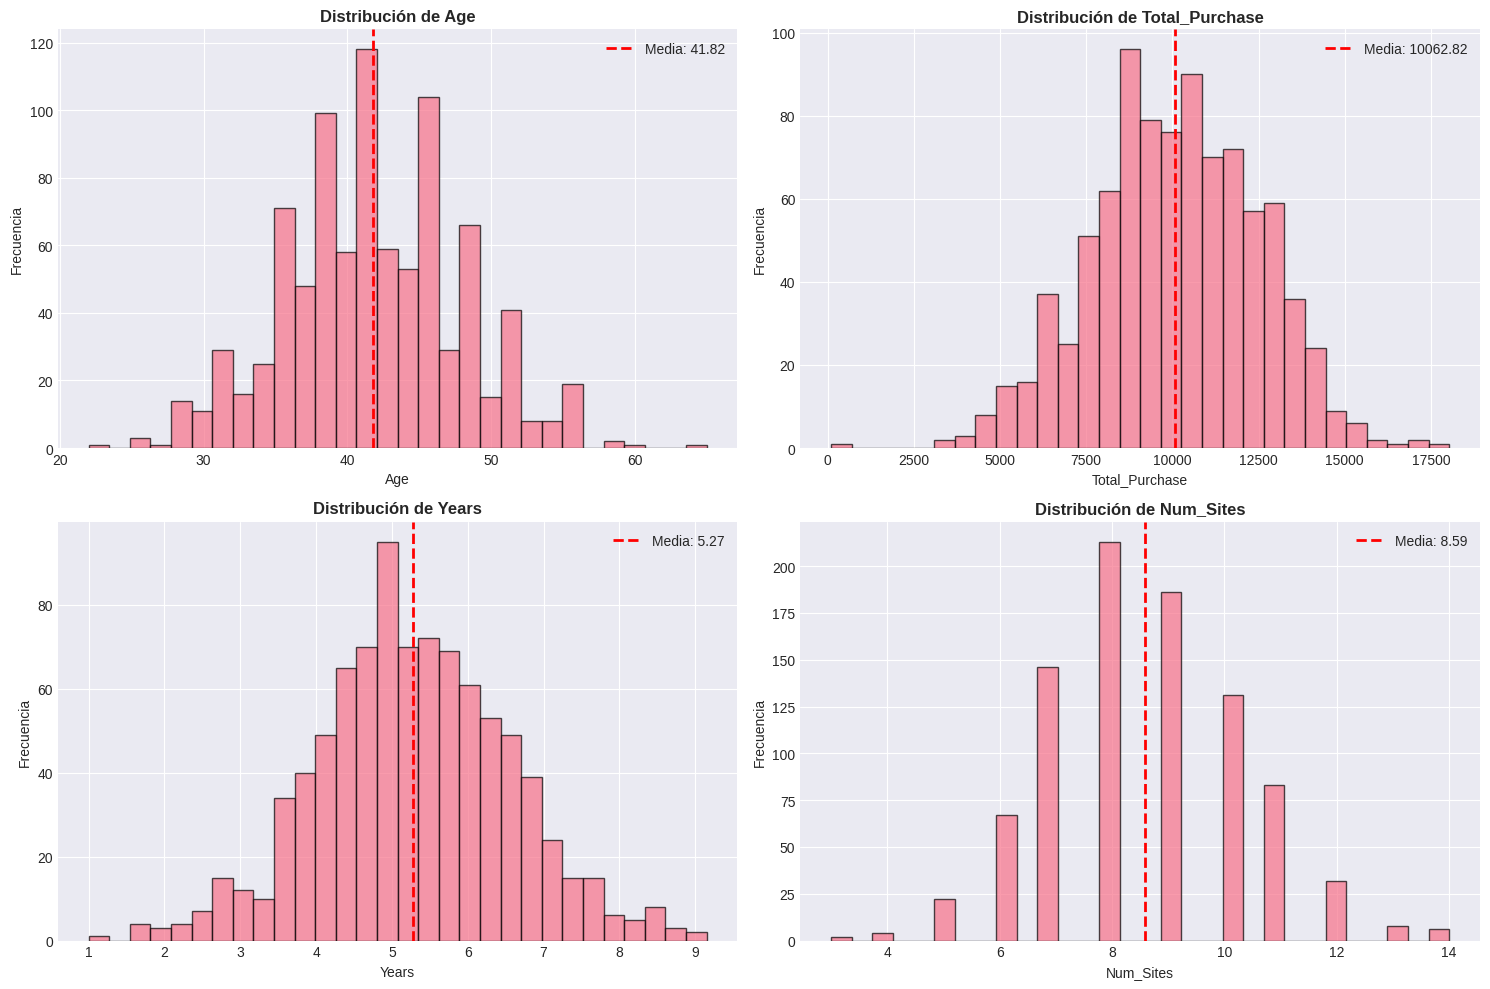

In [9]:
# 6. ANÁLISIS DE VARIABLES NUMÉRICAS
print("\n🔢 ANÁLISIS DE VARIABLES NUMÉRICAS")
print("-"*60)

# Seleccionar columnas numéricas
numeric_cols = ['Age', 'Total_Purchase', 'Years', 'Num_Sites']

# Distribución de variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--',
                      linewidth=2, label=f'Media: {df[col].mean():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()



COMPARACIÓN DE VARIABLES POR CHURN
------------------------------------------------------------


/tmp/ipython-input-776687689.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[idx], palette='Set2')
/tmp/ipython-input-776687689.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No Abandonó', 'Abandonó'])
/tmp/ipython-input-776687689.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[idx], palette='Set2')
/tmp/ipython-input-776687689.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No Aban

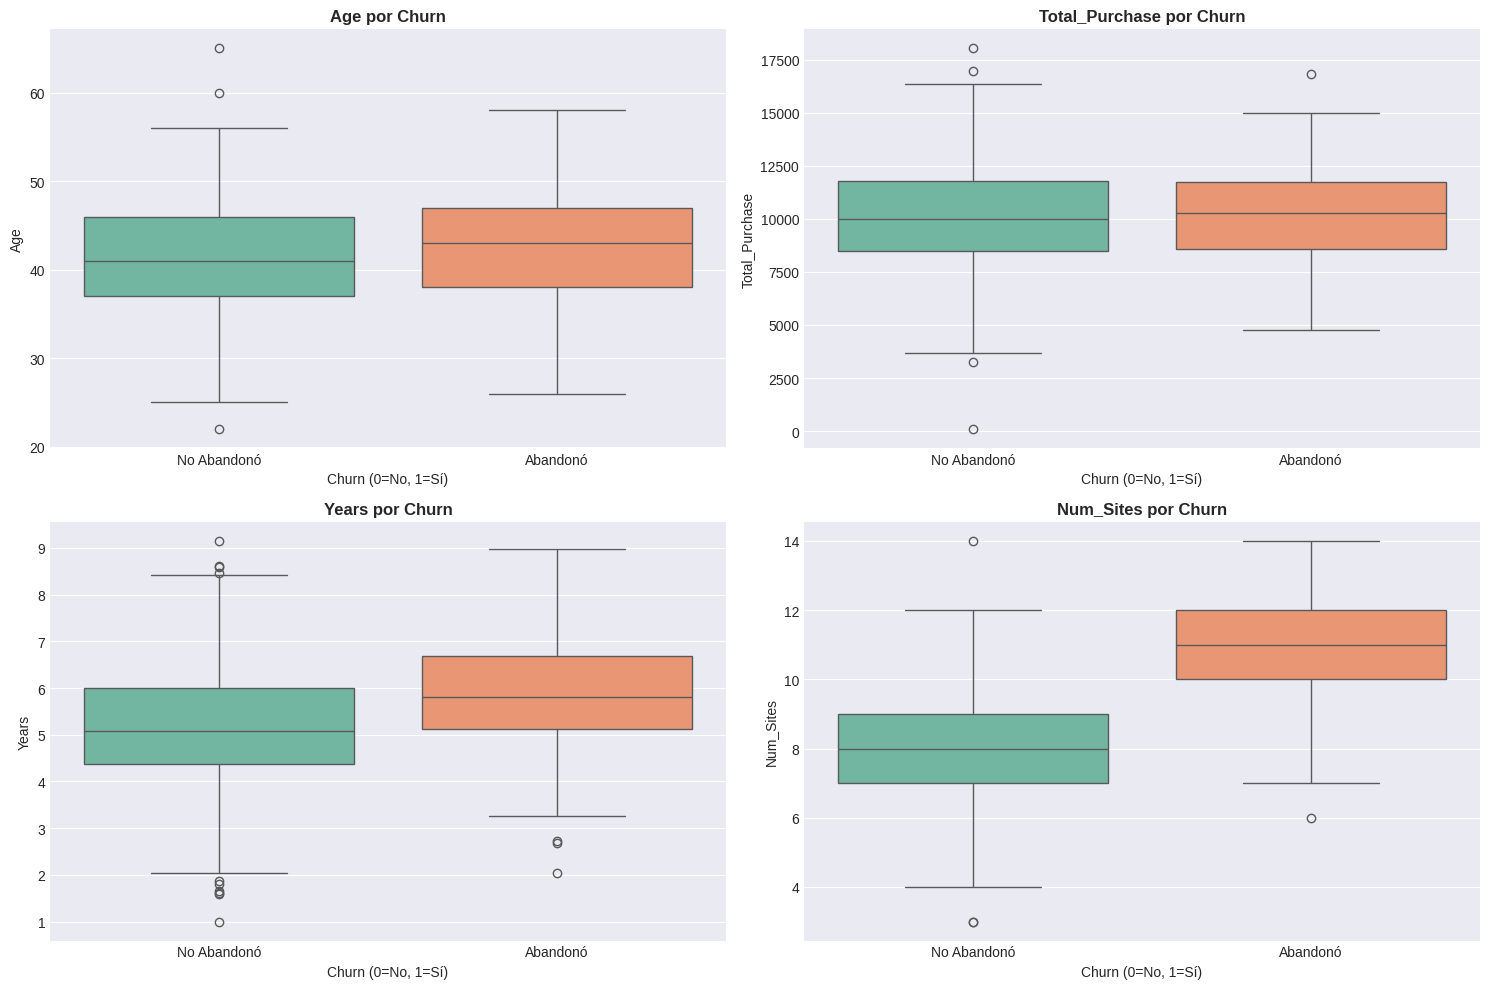


Estadísticas agrupadas por Churn:
             Age  Total_Purchase     Years  Num_Sites
Churn                                                
0      41.581333    10036.952853  5.151067   8.173333
1      42.993333    10192.179933  5.883600  10.660000


In [10]:
# 7. BOXPLOTS POR CHURN
print("\nCOMPARACIÓN DE VARIABLES POR CHURN")
print("-"*60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} por Churn', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Churn (0=No, 1=Sí)', fontsize=10)
    axes[idx].set_xticklabels(['No Abandonó', 'Abandonó'])

plt.tight_layout()
plt.show()

# Estadísticas por grupo de Churn
print("\nEstadísticas agrupadas por Churn:")
print(df.groupby('Churn')[numeric_cols].mean())




MATRIZ DE CORRELACIÓN
------------------------------------------------------------
                      Age  Total_Purchase     Years  Num_Sites  \
Age              1.000000       -0.037208  0.005625  -0.006070   
Total_Purchase  -0.037208        1.000000 -0.005623  -0.003390   
Years            0.005625       -0.005623  1.000000   0.051642   
Num_Sites       -0.006070       -0.003390  0.051642   1.000000   
Account_Manager -0.014749        0.015856  0.022930   0.033401   
Churn            0.085926        0.024031  0.214329   0.525398   

                 Account_Manager     Churn  
Age                    -0.014749  0.085926  
Total_Purchase          0.015856  0.024031  
Years                   0.022930  0.214329  
Num_Sites               0.033401  0.525398  
Account_Manager         1.000000  0.070611  
Churn                   0.070611  1.000000  


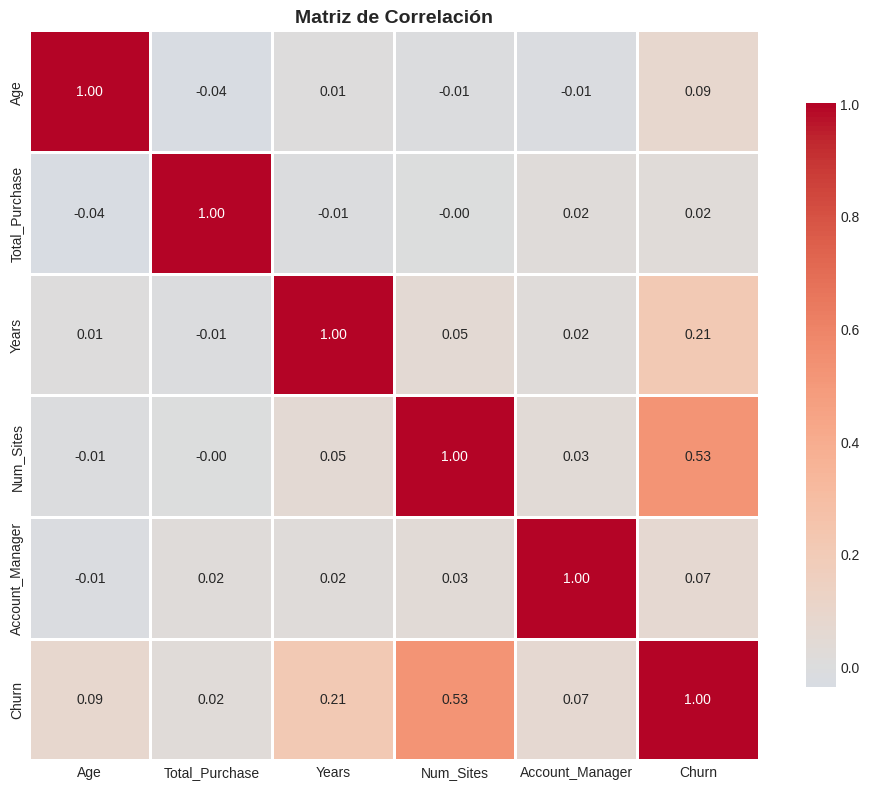

In [11]:
# 8. MATRIZ DE CORRELACIÓN
print("\nMATRIZ DE CORRELACIÓN")
print("-"*60)

# Crear matriz de correlación
correlation_cols = numeric_cols + ['Account_Manager', 'Churn']
corr_matrix = df[correlation_cols].corr()

print(corr_matrix)

# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=1, square=True, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


ANÁLISIS DE ACCOUNT MANAGER
------------------------------------------------------------

Porcentaje de Churn por Account Manager:
Churn                    0          1
Account_Manager                      
0                85.867238  14.132762
1                80.600462  19.399538


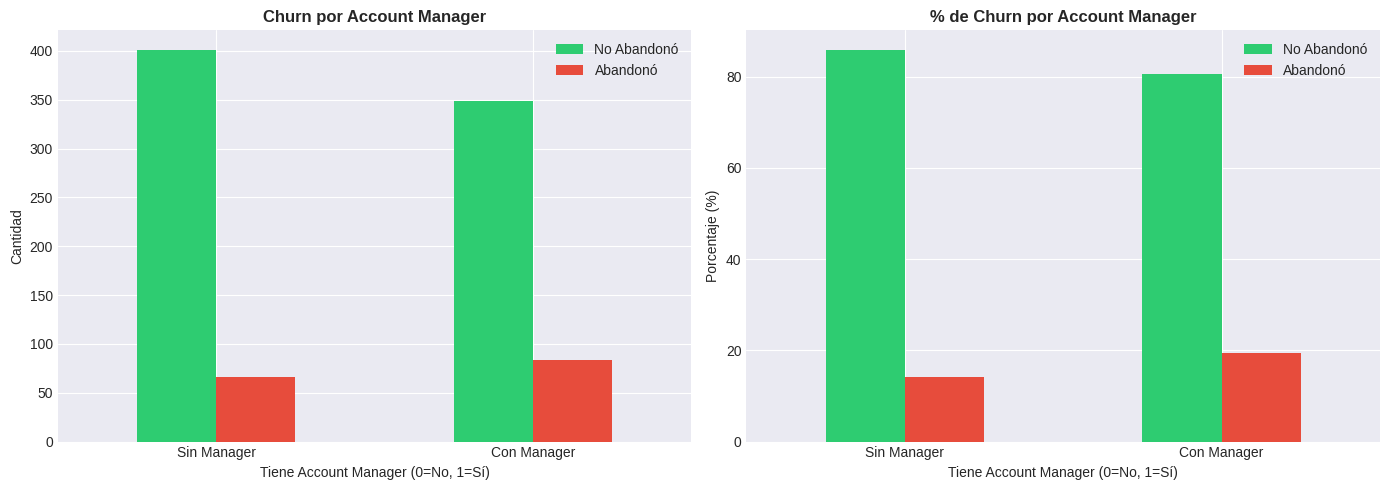

In [12]:
# 9. ANÁLISIS DE ACCOUNT MANAGER
print("\nANÁLISIS DE ACCOUNT MANAGER")
print("-"*60)

# Tabla cruzada
account_churn = pd.crosstab(df['Account_Manager'], df['Churn'],
                             normalize='index') * 100
print("\nPorcentaje de Churn por Account Manager:")
print(account_churn)

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
pd.crosstab(df['Account_Manager'], df['Churn']).plot(kind='bar',
                                                       ax=axes[0],
                                                       color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn por Account Manager', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tiene Account Manager (0=No, 1=Sí)', fontsize=10)
axes[0].set_ylabel('Cantidad', fontsize=10)
axes[0].set_xticklabels(['Sin Manager', 'Con Manager'], rotation=0)
axes[0].legend(['No Abandonó', 'Abandonó'])

# Porcentaje
account_churn.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('% de Churn por Account Manager', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tiene Account Manager (0=No, 1=Sí)', fontsize=10)
axes[1].set_ylabel('Porcentaje (%)', fontsize=10)
axes[1].set_xticklabels(['Sin Manager', 'Con Manager'], rotation=0)
axes[1].legend(['No Abandonó', 'Abandonó'])

plt.tight_layout()
plt.show()



 ANÁLISIS DE RELACIONES ENTRE VARIABLES
------------------------------------------------------------


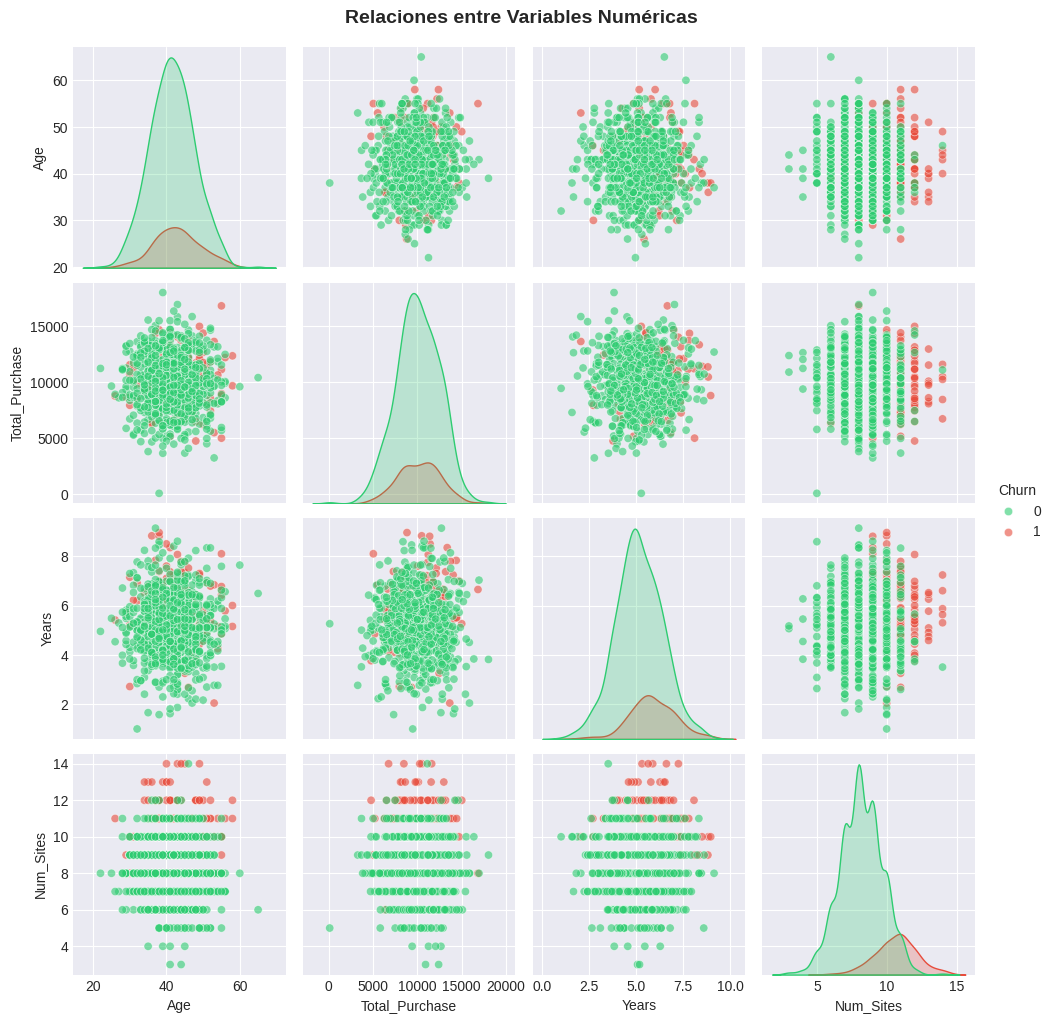

In [13]:
# 10. PAIRPLOT (RELACIONES ENTRE VARIABLES)
print("\n ANÁLISIS DE RELACIONES ENTRE VARIABLES")
print("-"*60)

# Pairplot
sns.pairplot(df[numeric_cols + ['Churn']], hue='Churn',
             palette={0: '#2ecc71', 1: '#e74c3c'},
             plot_kws={'alpha': 0.6}, height=2.5)
plt.suptitle('Relaciones entre Variables Numéricas', y=1.02,
             fontsize=14, fontweight='bold')
plt.show()

In [14]:
# 11. RESUMEN EJECUTIVO
print("RESUMEN")
print(f"Total de clientes: {len(df)}")
print(f"Clientes que abandonaron: {churn_counts[1]} ({churn_pct[1]:.2f}%)")
print(f"Clientes que NO abandonaron: {churn_counts[0]} ({churn_pct[0]:.2f}%)")
print(f"\nVariables numéricas disponibles: {numeric_cols}")
print(f"Variables categóricas: Names, Location, Company, Onboard_date")
print(f"\nClientes con Account Manager: {df['Account_Manager'].sum()}")
print(f"Clientes sin Account Manager: {len(df) - df['Account_Manager'].sum()}")

RESUMEN
Total de clientes: 900
Clientes que abandonaron: 150 (16.67%)
Clientes que NO abandonaron: 750 (83.33%)

Variables numéricas disponibles: ['Age', 'Total_Purchase', 'Years', 'Num_Sites']
Variables categóricas: Names, Location, Company, Onboard_date

Clientes con Account Manager: 433
Clientes sin Account Manager: 467


## Regresión Logística

In [15]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when
from pyspark.ml.feature import VectorAssembler, StandardScaler

from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

In [16]:
spark = SparkSession.builder.appName("Lab Spark Customer Churn").getOrCreate()
print("Spark version:", spark.version)

Spark version: 3.5.1


### Carga de datos

In [17]:
df_churn = spark.read.csv(
    'abandono_clientes.csv',
    header=True,
    inferSchema=True
)

### preparación de los datos para modelar

In [18]:
columnas_relevantes = ['Age', 'Total_Purchase', 'Account_Manager',
                        'Years', 'Num_Sites', 'Churn']

df_preparado = df_churn.select(columnas_relevantes)

In [19]:
df_churn.groupBy("Churn").count().show()

# Calcular proporción de clases
churn_ratio = df_preparado.filter(col('Churn') == 1).count() / df_preparado.count()
print(f"Proporción de Churn: {churn_ratio:.2%}")

+-----+-----+
|Churn|count|
+-----+-----+
|    1|  150|
|    0|  750|
+-----+-----+

Proporción de Churn: 16.67%


In [20]:
# División train/test estratificada
train_data, test_data = df_preparado.randomSplit([0.8, 0.2], seed=42)

print(f"Train set: {train_data.count()} registros")
train_data.groupBy("Churn").count().show()

print(f"Test set: {test_data.count()} registros")
test_data.groupBy("Churn").count().show()

Train set: 754 registros
+-----+-----+
|Churn|count|
+-----+-----+
|    1|  120|
|    0|  634|
+-----+-----+

Test set: 146 registros
+-----+-----+
|Churn|count|
+-----+-----+
|    1|   30|
|    0|  116|
+-----+-----+



In [21]:
# Variables principales
features_principales = ['Num_Sites', 'Years']

# Variables de contexto
features_contexto = ['Account_Manager']

# Variables secundarias
features_secundarias = ['Age', 'Total_Purchase']

# Todas las features
all_features = features_principales + features_contexto + features_secundarias

# Vector Assembler
assembler = VectorAssembler(
    inputCols=all_features,
    outputCol='features_raw'
)

# Scaler (importante para regresión logística)
scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withStd=True,
    withMean=True
)

### Modelo Baseline (sin balanceo)

In [22]:
lr_baseline = LogisticRegression(
    featuresCol='features',
    labelCol='Churn',
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    family='binomial'
)

pipeline_baseline = Pipeline(stages=[assembler, scaler, lr_baseline])

### Modelo con pesos balanceados

In [23]:
# Calcular peso para la clase minoritaria
weight_ratio = (1 - churn_ratio) / churn_ratio

# Crear columna de pesos
train_weighted = train_data.withColumn(
    'classWeights',
    when(col('Churn') == 1, weight_ratio).otherwise(1.0)
)

In [24]:
lr_weighted = LogisticRegression(
    featuresCol='features',
    labelCol='Churn',
    weightCol='classWeights',
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    family='binomial'
)

pipeline_weighted = Pipeline(stages=[assembler, scaler, lr_weighted])

### Modelo con Undersampling

In [25]:
# Separar clases
churn_1 = train_data.filter(col('Churn') == 1)
churn_0 = train_data.filter(col('Churn') == 0)

count_minority = churn_1.count()
count_majority = churn_0.count()

# Undersample de la clase mayoritaria
fraction = count_minority / count_majority
churn_0_undersampled = churn_0.sample(fraction=fraction, seed=42)

In [26]:
# Combinar datasets
train_balanced_under = churn_1.union(churn_0_undersampled)

print(f"   - Clase minoritaria: {churn_1.count()}")
print(f"   - Clase mayoritaria (original): {count_majority}")
print(f"   - Clase mayoritaria (undersampled): {churn_0_undersampled.count()}")
print(f"   - Total balanced: {train_balanced_under.count()}")

   - Clase minoritaria: 120
   - Clase mayoritaria (original): 634
   - Clase mayoritaria (undersampled): 107
   - Total balanced: 227


In [27]:
lr_undersampling = LogisticRegression(
    featuresCol='features',
    labelCol='Churn',
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    family='binomial'
)

pipeline_undersampling = Pipeline(stages=[assembler, scaler, lr_undersampling])

### Modelo con oversampling

In [28]:
# Calcular factor de oversampling
oversample_factor = count_majority / count_minority

# Oversample de la clase minoritaria (repetir registros)
churn_1_oversampled = churn_1.sample(
    withReplacement=True,
    fraction=oversample_factor,
    seed=42
)

In [29]:
# Combinar datasets
train_balanced_over = churn_0.union(churn_1_oversampled)

print(f"   - Clase minoritaria (oversampled): {churn_1_oversampled.count()}")
print(f"   - Clase mayoritaria: {count_majority}")
print(f"   - Total balanced: {train_balanced_over.count()}")

   - Clase minoritaria (oversampled): 664
   - Clase mayoritaria: 634
   - Total balanced: 1298


In [30]:
lr_oversampling = LogisticRegression(
    featuresCol='features',
    labelCol='Churn',
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    family='binomial'
)

pipeline_oversampling = Pipeline(stages=[assembler, scaler, lr_oversampling])

### Evaluación y entrenamiento

In [31]:
def evaluar_modelo(modelo, train_df, test_df, nombre_modelo):
    """Función para entrenar y evaluar un modelo"""
    print(f"EVALUANDO: {nombre_modelo}")

    # Entrenar
    modelo_fit = modelo.fit(train_df)

    # Predicciones
    predictions_train = modelo_fit.transform(train_df)
    predictions_test = modelo_fit.transform(test_df)

    # Evaluadores
    evaluator_auc = BinaryClassificationEvaluator(
        labelCol='Churn',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderROC'
    )

    evaluator_accuracy = MulticlassClassificationEvaluator(
        labelCol='Churn',
        predictionCol='prediction',
        metricName='accuracy'
    )

    evaluator_precision = MulticlassClassificationEvaluator(
        labelCol='Churn',
        predictionCol='prediction',
        metricName='weightedPrecision'
    )

    evaluator_recall = MulticlassClassificationEvaluator(
        labelCol='Churn',
        predictionCol='prediction',
        metricName='weightedRecall'
    )

    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol='Churn',
        predictionCol='prediction',
        metricName='f1'
    )

    # Métricas Train
    auc_train = evaluator_auc.evaluate(predictions_train)
    acc_train = evaluator_accuracy.evaluate(predictions_train)
    prec_train = evaluator_precision.evaluate(predictions_train)
    rec_train = evaluator_recall.evaluate(predictions_train)
    f1_train = evaluator_f1.evaluate(predictions_train)

    # Métricas Test
    auc_test = evaluator_auc.evaluate(predictions_test)
    acc_test = evaluator_accuracy.evaluate(predictions_test)
    prec_test = evaluator_precision.evaluate(predictions_test)
    rec_test = evaluator_recall.evaluate(predictions_test)
    f1_test = evaluator_f1.evaluate(predictions_test)

    print("\nMÉTRICAS DE ENTRENAMIENTO:")
    print(f"  AUC-ROC:   {auc_train:.4f}")
    print(f"  Accuracy:  {acc_train:.4f}")
    print(f"  Precision: {prec_train:.4f}")
    print(f"  Recall:    {rec_train:.4f}")
    print(f"  F1-Score:  {f1_train:.4f}")

    print("\nMÉTRICAS DE TEST:")
    print(f"  AUC-ROC:   {auc_test:.4f}")
    print(f"  Accuracy:  {acc_test:.4f}")
    print(f"  Precision: {prec_test:.4f}")
    print(f"  Recall:    {rec_test:.4f}")
    print(f"  F1-Score:  {f1_test:.4f}")

    # Matriz de confusión
    print("\nMATRIZ DE CONFUSIÓN (Test):")
    predictions_test.groupBy('Churn', 'prediction').count().show()

    return {
        'modelo': modelo_fit,
        'metricas': {
            'train': {
                'auc': auc_train, 'accuracy': acc_train,
                'precision': prec_train, 'recall': rec_train, 'f1': f1_train
            },
            'test': {
                'auc': auc_test, 'accuracy': acc_test,
                'precision': prec_test, 'recall': rec_test, 'f1': f1_test
            }
        }
    }

In [32]:
# Entrenar todos los modelos
resultados = {}

resultados['baseline'] = evaluar_modelo(
    pipeline_baseline, train_data, test_data, "MODELO BASELINE"
)

EVALUANDO: MODELO BASELINE

MÉTRICAS DE ENTRENAMIENTO:
  AUC-ROC:   0.9011
  Accuracy:  0.8926
  Precision: 0.8838
  Recall:    0.8926
  F1-Score:  0.8820

MÉTRICAS DE TEST:
  AUC-ROC:   0.9371
  Accuracy:  0.8767
  Precision: 0.8765
  Recall:    0.8767
  F1-Score:  0.8615

MATRIZ DE CONFUSIÓN (Test):
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    1|       0.0|   16|
|    0|       0.0|  114|
|    1|       1.0|   14|
|    0|       1.0|    2|
+-----+----------+-----+



In [33]:
resultados['weighted'] = evaluar_modelo(
    pipeline_weighted, train_weighted, test_data, "MODELO CON CLASS WEIGHTS"
)

EVALUANDO: MODELO CON CLASS WEIGHTS

MÉTRICAS DE ENTRENAMIENTO:
  AUC-ROC:   0.9009
  Accuracy:  0.8355
  Precision: 0.8869
  Recall:    0.8355
  F1-Score:  0.8508

MÉTRICAS DE TEST:
  AUC-ROC:   0.9382
  Accuracy:  0.8630
  Precision: 0.8855
  Recall:    0.8630
  F1-Score:  0.8697

MATRIZ DE CONFUSIÓN (Test):
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    1|       0.0|    5|
|    0|       0.0|  101|
|    1|       1.0|   25|
|    0|       1.0|   15|
+-----+----------+-----+



In [34]:
resultados['undersampling'] = evaluar_modelo(
    pipeline_undersampling, train_balanced_under, test_data, "MODELO CON UNDERSAMPLING"
)

EVALUANDO: MODELO CON UNDERSAMPLING

MÉTRICAS DE ENTRENAMIENTO:
  AUC-ROC:   0.8933
  Accuracy:  0.8150
  Precision: 0.8150
  Recall:    0.8150
  F1-Score:  0.8150

MÉTRICAS DE TEST:
  AUC-ROC:   0.9385
  Accuracy:  0.8630
  Precision: 0.8972
  Recall:    0.8630
  F1-Score:  0.8716

MATRIZ DE CONFUSIÓN (Test):
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    1|       0.0|    3|
|    0|       0.0|   99|
|    1|       1.0|   27|
|    0|       1.0|   17|
+-----+----------+-----+



In [35]:
resultados['oversampling'] = evaluar_modelo(
    pipeline_oversampling, train_balanced_over, test_data, "MODELO CON OVERSAMPLING"
)

EVALUANDO: MODELO CON OVERSAMPLING

MÉTRICAS DE ENTRENAMIENTO:
  AUC-ROC:   0.8993
  Accuracy:  0.8290
  Precision: 0.8290
  Recall:    0.8290
  F1-Score:  0.8290

MÉTRICAS DE TEST:
  AUC-ROC:   0.9394
  Accuracy:  0.8630
  Precision: 0.8912
  Recall:    0.8630
  F1-Score:  0.8707

MATRIZ DE CONFUSIÓN (Test):
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    1|       0.0|    4|
|    0|       0.0|  100|
|    1|       1.0|   26|
|    0|       1.0|   16|
+-----+----------+-----+



### Comparación de modelos

In [36]:
comparacion_data = []
for nombre, resultado in resultados.items():
    metricas = resultado['metricas']['test']
    comparacion_data.append({
        'Modelo': nombre,
        'AUC-ROC': f"{metricas['auc']:.4f}",
        'Accuracy': f"{metricas['accuracy']:.4f}",
        'Precision': f"{metricas['precision']:.4f}",
        'Recall': f"{metricas['recall']:.4f}",
        'F1-Score': f"{metricas['f1']:.4f}"
    })

df_comparacion = pd.DataFrame(comparacion_data)
print("\n", df_comparacion.to_string(index=False))


        Modelo AUC-ROC Accuracy Precision Recall F1-Score
     baseline  0.9371   0.8767    0.8765 0.8767   0.8615
     weighted  0.9382   0.8630    0.8855 0.8630   0.8697
undersampling  0.9385   0.8630    0.8972 0.8630   0.8716
 oversampling  0.9394   0.8630    0.8912 0.8630   0.8707


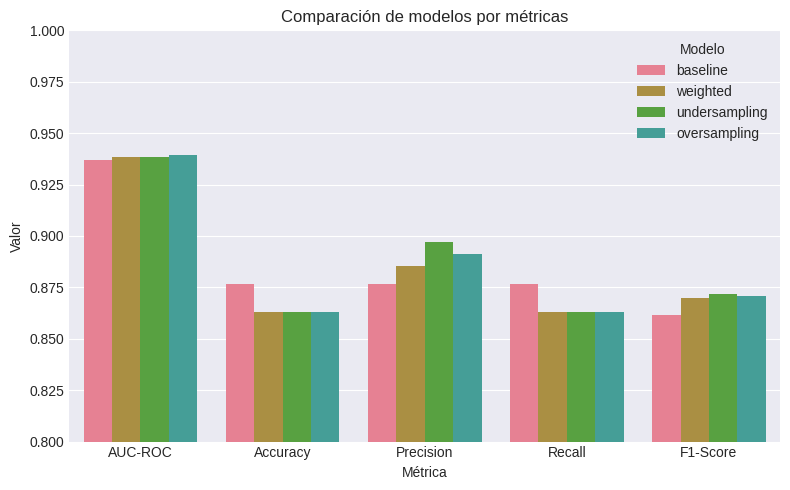

In [98]:
# Datos de ejemplo (los tuyos)
data = [
    {'Modelo': 'baseline', 'AUC-ROC': 0.9371, 'Accuracy': 0.8767, 'Precision': 0.8765, 'Recall': 0.8767, 'F1-Score': 0.8615},
    {'Modelo': 'weighted', 'AUC-ROC': 0.9382, 'Accuracy': 0.8630, 'Precision': 0.8855, 'Recall': 0.8630, 'F1-Score': 0.8697},
    {'Modelo': 'undersampling', 'AUC-ROC': 0.9385, 'Accuracy': 0.8630, 'Precision': 0.8972, 'Recall': 0.8630, 'F1-Score': 0.8716},
    {'Modelo': 'oversampling', 'AUC-ROC': 0.9394, 'Accuracy': 0.8630, 'Precision': 0.8912, 'Recall': 0.8630, 'F1-Score': 0.8707},
]

df_comparacion = pd.DataFrame(data)

# Convertir de formato ancho a largo para graficar fácilmente
df_melt = df_comparacion.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(8, 5))
sns.barplot(data=df_melt, x='Métrica', y='Valor', hue='Modelo')
plt.title('Comparación de modelos por métricas')
plt.ylim(0.8, 1.0)
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()

### El mejor modelo

In [37]:
modelo_lr = resultados['undersampling']['modelo'].stages[-1]
coeficientes = modelo_lr.coefficients.toArray()
intercepto = modelo_lr.intercept

coef_data = []
for i, feature in enumerate(all_features):
    coef_data.append({
        'Feature': feature,
        'Coeficiente': f"{coeficientes[i]:.6f}",
        'Abs_Coef': abs(coeficientes[i])
    })

In [38]:
df_coef = pd.DataFrame(coef_data).sort_values('Abs_Coef', ascending=False)
print(df_coef[['Feature', 'Coeficiente']].to_string(index=False))
print(f"\nIntercepto: {intercepto:.6f}")

        Feature Coeficiente
      Num_Sites    1.669825
          Years    0.642635
            Age    0.392850
Account_Manager    0.164346
 Total_Purchase   -0.038620

Intercepto: 0.151971


#### **Grid Seatch con Cross-Validation**

In [73]:
# Crear grid de hiperparámetros
param_grid = ParamGridBuilder() \
    .addGrid(lr_undersampling.regParam, [0.0, 0.001, 0.01, 0.1, 0.5, 1.0]) \
    .addGrid(lr_undersampling.elasticNetParam, [0.0, 0.2, 0.5, 0.8, 1.0]) \
    .addGrid(lr_undersampling.maxIter, [50, 100, 200]) \
    .addGrid(lr_undersampling.threshold, [0.6, 0.7]) \
    .build()

In [74]:
# Evaluadores para diferentes métricas
evaluator_auc = BinaryClassificationEvaluator(
    labelCol='Churn',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)

evaluator_pr = BinaryClassificationEvaluator(
    labelCol='Churn',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderPR'  # Precision-Recall
)

In [77]:
# CrossValidator con AUC-ROC
cv_auc = CrossValidator(
    estimator=pipeline_undersampling,
    estimatorParamMaps=param_grid,
    evaluator=evaluator_auc,
    numFolds=5,
    seed=42,
    parallelism=2,  # Ajustar según recursos
    collectSubModels=False
)

In [78]:
# Entrenar
cv_model_auc = cv_auc.fit(train_balanced_under)

#### **análisis de resultados**

In [79]:
print("MEJORES HIPERPARÁMETROS (optimizando AUC-ROC)")

best_model = cv_model_auc.bestModel
best_lr = best_model.stages[-1]

print(f"\n  regParam:         {best_lr.getRegParam()}")
print(f"  elasticNetParam:  {best_lr.getElasticNetParam()}")
print(f"  maxIter:          {best_lr.getMaxIter()}")
print(f"  threshold:        {best_lr.getThreshold()}")

MEJORES HIPERPARÁMETROS (optimizando AUC-ROC)

  regParam:         0.1
  elasticNetParam:  0.2
  maxIter:          50
  threshold:        0.6


In [80]:
# Predicciones
predictions_train = cv_model_auc.transform(train_balanced_under)
predictions_test = cv_model_auc.transform(test_data)

# Evaluadores adicionales
evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol='Churn', predictionCol='prediction', metricName='accuracy'
)
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol='Churn', predictionCol='prediction', metricName='weightedPrecision'
)
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol='Churn', predictionCol='prediction', metricName='weightedRecall'
)
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol='Churn', predictionCol='prediction', metricName='f1'
)

In [81]:
# Métricas Test
auc_test = evaluator_auc.evaluate(predictions_test)
pr_test = evaluator_pr.evaluate(predictions_test)
acc_test = evaluator_accuracy.evaluate(predictions_test)
prec_test = evaluator_precision.evaluate(predictions_test)
rec_test = evaluator_recall.evaluate(predictions_test)
f1_test = evaluator_f1.evaluate(predictions_test)

print("MÉTRICAS EN TEST SET:")
print(f"  AUC-ROC:        {auc_test:.4f}")
print(f"  AUC-PR:         {pr_test:.4f}")
print(f"  Accuracy:       {acc_test:.4f}")
print(f"  Precision:      {prec_test:.4f}")
print(f"  Recall:         {rec_test:.4f}")
print(f"  F1-Score:       {f1_test:.4f}")

MÉTRICAS EN TEST SET:
  AUC-ROC:        0.9376
  AUC-PR:         0.8335
  Accuracy:       0.8973
  Precision:      0.8986
  Recall:         0.8973
  F1-Score:       0.8979


MATRIZ DE CONFUSIÓN (Test):
+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    0|       0.0|  108|
|    0|       1.0|    8|
|    1|       0.0|    7|
|    1|       1.0|   23|
+-----+----------+-----+



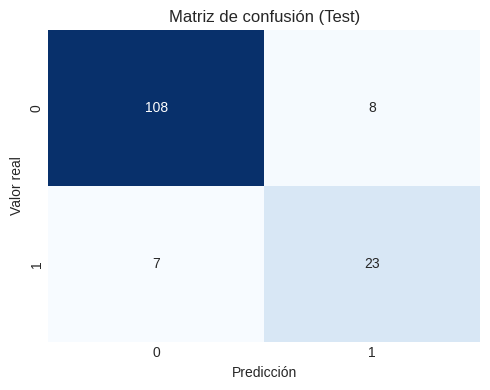

In [100]:
print("MATRIZ DE CONFUSIÓN (Test):")
predictions_test.groupBy('Churn', 'prediction').count().orderBy('Churn', 'prediction').show()

# Matriz de confusión
matriz = np.array([[108, 8],
                   [7, 23]])

plt.figure(figsize=(5,4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Matriz de confusión (Test)')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()


In [84]:
print("MÉTRICAS POR CLASE:")
tp = predictions_test.filter((col('Churn') == 1) & (col('prediction') == 1)).count()
tn = predictions_test.filter((col('Churn') == 0) & (col('prediction') == 0)).count()
fp = predictions_test.filter((col('Churn') == 0) & (col('prediction') == 1)).count()
fn = predictions_test.filter((col('Churn') == 1) & (col('prediction') == 0)).count()

precision_churn = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_churn = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_churn = 2 * (precision_churn * recall_churn) / (precision_churn + recall_churn) if (precision_churn + recall_churn) > 0 else 0

print(f"\nPara clase CHURN=1 (los que abandonan):")
print(f"  Precision: {precision_churn:.4f} (de los que predecimos churn, cuántos sí son)")
print(f"  Recall:    {recall_churn:.4f} (de todos los churn reales, cuántos detectamos)")
print(f"  F1-Score:  {f1_churn:.4f}")

MÉTRICAS POR CLASE:

Para clase CHURN=1 (los que abandonan):
  Precision: 0.7419 (de los que predecimos churn, cuántos sí son)
  Recall:    0.7667 (de todos los churn reales, cuántos detectamos)
  F1-Score:  0.7541


### Predicción de valores reales

In [85]:
df_new = spark.read.csv(
    'clientes_nuevos.csv',
    header=True,
    inferSchema=True
)

In [86]:
# Verificar que tenga las mismas columnas que el modelo espera
columnas_modelo = ['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites']
columnas_faltantes = [col for col in columnas_modelo if col not in df_new.columns]

if columnas_faltantes:
    print(f"ADVERTENCIA: Faltan columnas: {columnas_faltantes}")
else:
    print(f"Todas las columnas necesarias están presentes")

Todas las columnas necesarias están presentes


In [87]:
predicciones_new = cv_model_auc.transform(df_new)
print(f"Predicciones generadas para {predicciones_new.count()} clientes")

Predicciones generadas para 6 clientes


In [88]:
from pyspark.sql.functions import round as spark_round, udf
from pyspark.sql.types import DoubleType

# Función UDF para extraer probabilidad de churn
def extract_prob(probability_vector):
    """Extrae la probabilidad de la clase 1 (churn)"""
    return float(probability_vector[1])

extract_prob_udf = udf(extract_prob, DoubleType())

# Agregar columna con probabilidad de churn
predicciones_new = predicciones_new.withColumn(
    'prob_churn',
    spark_round(extract_prob_udf(col('probability')), 4)
)

In [90]:
# IMPORTANTE: Usar threshold óptimo
THRESHOLD_OPTIMO = 0.6

# Crear predicción con threshold óptimo
predicciones_new = predicciones_new.withColumn(
    'prediction_optimal',
    when(col('prob_churn') >= THRESHOLD_OPTIMO, 1).otherwise(0)
)

# Etiquetar predicciones de forma legible
predicciones_new = predicciones_new.withColumn(
    'riesgo_churn',
    when(col('prob_churn') >= 0.7, 'MUY ALTO')
    .when(col('prob_churn') >= 0.5, 'ALTO')
    .when(col('prob_churn') >= 0.3, 'MEDIO')
    .otherwise('BAJO')
)

predicciones_new = predicciones_new.withColumn(
    'prediccion_final',
    when(col('prediction_optimal') == 1, 'CHURN')
    .otherwise('NO CHURN')
)

In [91]:
print("DISTRIBUCIÓN DE PREDICCIONES:")
predicciones_new.groupBy('prediccion_final').count().orderBy('count', ascending=False).show()

total_clientes = predicciones_new.count()
clientes_churn = predicciones_new.filter(col('prediction_optimal') == 1).count()
clientes_no_churn = predicciones_new.filter(col('prediction_optimal') == 0).count()

print(f"Total de clientes: {total_clientes}")
print(f"Predicción CHURN: {clientes_churn} ({clientes_churn/total_clientes*100:.1f}%)")
print(f"Predicción NO CHURN: {clientes_no_churn} ({clientes_no_churn/total_clientes*100:.1f}%)")

DISTRIBUCIÓN DE PREDICCIONES:
+----------------+-----+
|prediccion_final|count|
+----------------+-----+
|           CHURN|    4|
|        NO CHURN|    2|
+----------------+-----+

Total de clientes: 6
Predicción CHURN: 4 (66.7%)
Predicción NO CHURN: 2 (33.3%)
